# CP4 — Case iFood
## Parte 2 — Machine Learning & Modelling

Este notebook utiliza o dataset do Case iFood, previamente estruturado e validado no Oracle Database na Parte 1 do trabalho.

A seleção das variáveis segue a query documentada no arquivo `04_validation_and_ml_query.sql`.

O objetivo desta etapa é desenvolver uma versão melhorada do modelo Decision Tree apresentado no Case iFood, utilizando:

- análise exploratória objetiva;
- Feature Engineering;
- HoldOut estratificado;
- tuning de hiperparâmetros;
- avaliação por Precision, Recall, F1-score e ROC AUC;
- prevenção de data leakage.

## 1. Importação das bibliotecas

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

pd.set_option("display.max_columns", None)

## 2. Carregamento dos dados

Os dados utilizados correspondem ao dataset carregado na tabela `IFOOD_CUSTOMERS` do Oracle.

Para manter o notebook reproduzível localmente, o mesmo dataset original é carregado a partir do arquivo `data.csv`.

In [28]:
df = pd.read_csv("../data/data.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


## 3. Conferência inicial dos dados

Nesta etapa são verificadas as dimensões do dataset, os tipos das variáveis, valores ausentes e a distribuição inicial da variável alvo `Response`.

In [29]:
df.shape

(2240, 29)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [31]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [32]:
df["Response"].value_counts()

Response
0    1906
1     334
Name: count, dtype: int64

In [33]:
df["Response"].value_counts(normalize=True)

Response
0    0.850893
1    0.149107
Name: proportion, dtype: float64

In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


### Observações iniciais

- O dataset possui 2240 registros.
- A variável `Income` possui valores ausentes.
- A variável alvo `Response` é desbalanceada, com predominância da classe 0.
- Essa característica será considerada posteriormente por meio de separação estratificada e tuning do modelo.

## 4. Tratamento inicial dos dados

Antes da análise exploratória, são realizados ajustes mínimos para permitir a criação das novas variáveis e manter consistência com o Case iFood apresentado em aula.

A variável `Income` possui valores ausentes. Nesta etapa, os valores nulos serão apenas identificados e preservados. O tratamento definitivo será realizado posteriormente dentro do pipeline de Machine Learning, evitando vazamento de dados.

In [35]:
df_ml = df.copy()

df_ml["Dt_Customer"] = pd.to_datetime(
    df_ml["Dt_Customer"],
    format="%Y-%m-%d",
    errors="coerce"
)

print("Valores nulos em Income:", df_ml["Income"].isna().sum())
print("Datas inválidas:", df_ml["Dt_Customer"].isna().sum())

Valores nulos em Income: 24
Datas inválidas: 0


## 5. Feature Engineering

O Case iFood apresentado em aula utiliza transformação de variáveis originais para representar melhor o perfil e o comportamento dos clientes.

Neste trabalho, são criadas novas features agregadas a partir de informações já disponíveis no momento da campanha. Nenhuma delas utiliza a variável alvo `Response`.

### 5.1 Idade do cliente

O notebook de aula transforma `Year_Birth` em idade. Para evitar utilizar o ano atual e tornar a análise reproduzível, será utilizado um ano de referência fixo compatível com o período do dataset.

In [36]:
REFERENCE_YEAR = 2017

df_ml["Age"] = REFERENCE_YEAR - df_ml["Year_Birth"]

df_ml[["Year_Birth", "Age"]].describe()

,Year_Birth,Age
count,2240.000000,2240.000000
mean,1968.805804,48.194196
std,11.984069,11.984069
min,1893.000000,21.000000
25%,1959.000000,40.000000
50%,1970.000000,47.000000
75%,1977.000000,58.000000
max,1996.000000,124.000000


### 5.2 Tempo como cliente

A data de cadastro `Dt_Customer` permite representar há quanto tempo o consumidor fazia parte da base. Essa variável pode capturar diferenças entre clientes novos e antigos.

In [37]:
REFERENCE_DATE = pd.Timestamp("2017-01-01")

df_ml["Customer_Tenure_Days"] = (
    REFERENCE_DATE - df_ml["Dt_Customer"]
).dt.days

df_ml["Customer_Tenure_Days"].describe()

count    2240.000000
mean     1270.582143
std       202.122512
min       917.000000
25%      1097.750000
50%      1272.500000
75%      1446.000000
max      1616.000000
Name: Customer_Tenure_Days, dtype: float64

### 5.3 Total de filhos no domicílio

As variáveis `Kidhome` e `Teenhome` representam crianças e adolescentes presentes no domicílio. A soma das duas fornece uma medida simples da quantidade total de dependentes.

In [38]:
df_ml["Total_Children"] = (
    df_ml["Kidhome"] +
    df_ml["Teenhome"]
)

df_ml["Total_Children"].value_counts().sort_index()

Total_Children
0     638
1    1128
2     421
3      53
Name: count, dtype: int64

### 5.4 Gasto total

As variáveis `Mnt...` representam gastos em diferentes categorias de produtos. A soma dessas categorias cria uma medida agregada do valor total consumido pelo cliente.

In [39]:
spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df_ml["Total_Spent"] = df_ml[spending_cols].sum(axis=1)

df_ml["Total_Spent"].describe()

count    2240.000000
mean      605.798214
std       602.249288
min         5.000000
25%        68.750000
50%       396.000000
75%      1045.500000
max      2525.000000
Name: Total_Spent, dtype: float64

### 5.5 Total de compras

As compras realizadas pela web, catálogo e loja física representam canais diferentes de consumo. A soma fornece uma visão agregada da atividade de compra do cliente.

In [40]:
purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df_ml["Total_Purchases"] = df_ml[purchase_cols].sum(axis=1)

df_ml["Total_Purchases"].describe()

count    2240.000000
mean       12.537054
std         7.205741
min         0.000000
25%         6.000000
50%        12.000000
75%        18.000000
max        32.000000
Name: Total_Purchases, dtype: float64

### 5.6 Campanhas anteriores aceitas

As variáveis `AcceptedCmp1` até `AcceptedCmp5` representam respostas a campanhas anteriores. A soma dessas variáveis indica o histórico de aceitação de campanhas do cliente.

Essa feature não utiliza `Response`, que representa a resposta da campanha atual.

In [41]:
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

df_ml["Accepted_Campaigns"] = df_ml[campaign_cols].sum(axis=1)

df_ml["Accepted_Campaigns"].value_counts().sort_index()

Accepted_Campaigns
0    1777
1     325
2      83
3      44
4      11
Name: count, dtype: int64

### 5.7 Ticket médio aproximado

A relação entre gasto total e quantidade total de compras cria uma estimativa simples do valor médio gasto por compra.

In [42]:
df_ml["Average_Ticket"] = np.where(
    df_ml["Total_Purchases"] > 0,
    df_ml["Total_Spent"] / df_ml["Total_Purchases"],
    0
)

df_ml["Average_Ticket"].describe()

count    2240.000000
mean       38.103486
std        45.910552
min         0.000000
25%        13.000000
50%        29.642857
75%        49.135417
max      1679.000000
Name: Average_Ticket, dtype: float64

## 6. Análise Exploratória de Dados — EDA

A EDA a seguir tem como objetivo verificar diferenças de perfil e comportamento entre clientes que responderam ou não à campanha e justificar as variáveis utilizadas posteriormente no modelo.

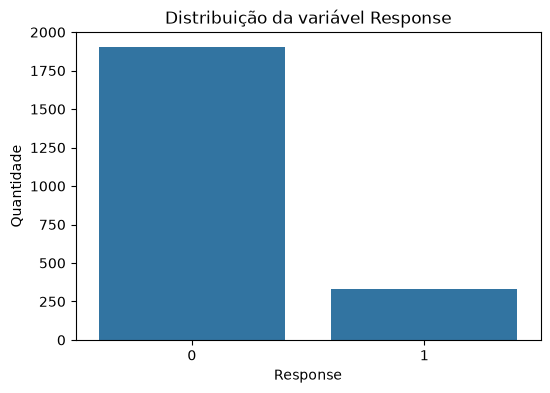

Response
0    1906
1     334
Name: count, dtype: int64
Response
0    0.850893
1    0.149107
Name: proportion, dtype: float64


In [43]:
response_counts = df_ml["Response"].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.countplot(data=df_ml, x="Response")
plt.title("Distribuição da variável Response")
plt.xlabel("Response")
plt.ylabel("Quantidade")
plt.show()

print(response_counts)
print(df_ml["Response"].value_counts(normalize=True).sort_index())

### Interpretação

A variável alvo apresenta desbalanceamento entre as classes, com predominância de clientes que não responderam à campanha. Esse resultado justifica o uso de HoldOut estratificado e métricas além da acurácia, como Precision, Recall, F1-score e ROC AUC.

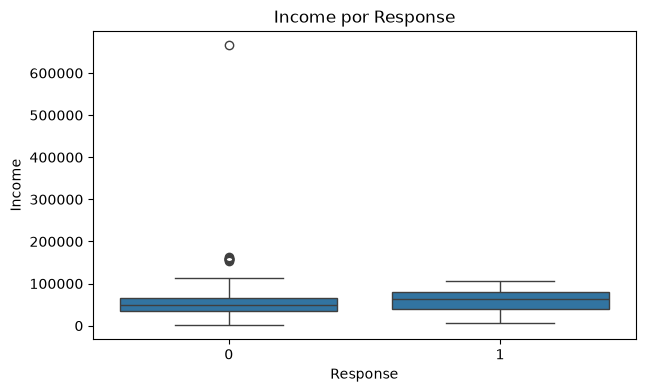

In [44]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_ml, x="Response", y="Income")
plt.title("Income por Response")
plt.xlabel("Response")
plt.ylabel("Income")
plt.show()

### Interpretação

A distribuição de renda será analisada entre as duas classes para verificar se o nível de renda apresenta relação com a resposta à campanha. Os valores ausentes de `Income` serão tratados posteriormente dentro do pipeline.

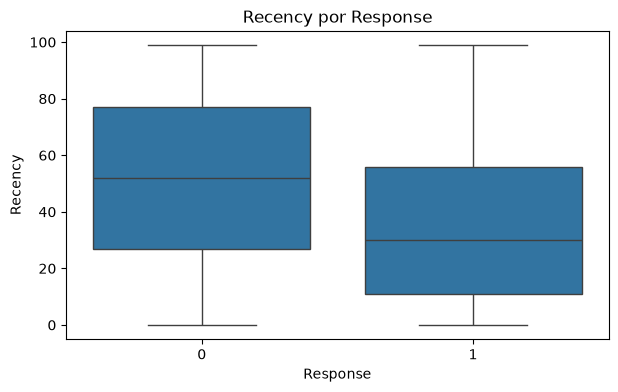

In [45]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_ml, x="Response", y="Recency")
plt.title("Recency por Response")
plt.xlabel("Response")
plt.ylabel("Recency")
plt.show()

### Interpretação

`Recency` representa o tempo desde a última compra. Diferenças entre as classes podem indicar que clientes que compraram mais recentemente apresentam comportamento distinto em relação à campanha.

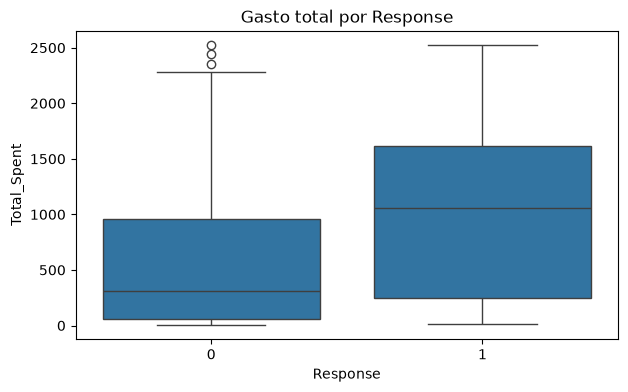

In [46]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_ml, x="Response", y="Total_Spent")
plt.title("Gasto total por Response")
plt.xlabel("Response")
plt.ylabel("Total_Spent")
plt.show()

### Interpretação

O gasto total resume o consumo do cliente em diferentes categorias. A comparação entre as classes permite avaliar se clientes com maior nível de consumo apresentam maior tendência de resposta.

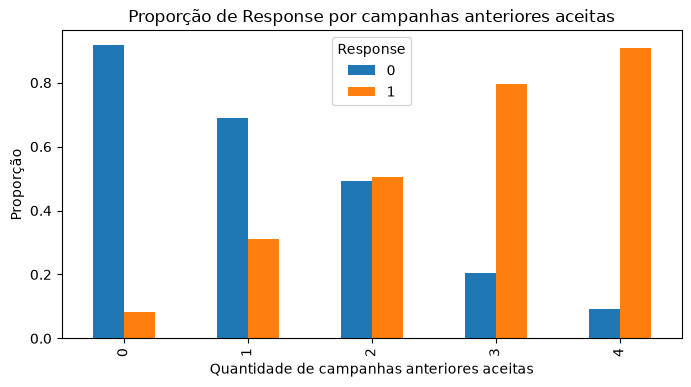

In [47]:
campaign_response = pd.crosstab(
    df_ml["Accepted_Campaigns"],
    df_ml["Response"],
    normalize="index"
)

campaign_response.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Proporção de Response por campanhas anteriores aceitas")
plt.xlabel("Quantidade de campanhas anteriores aceitas")
plt.ylabel("Proporção")
plt.legend(title="Response")
plt.show()

### Interpretação

O histórico de campanhas anteriores pode indicar maior ou menor propensão a aceitar novas campanhas. Essa análise ajuda a justificar a feature agregada `Accepted_Campaigns`.

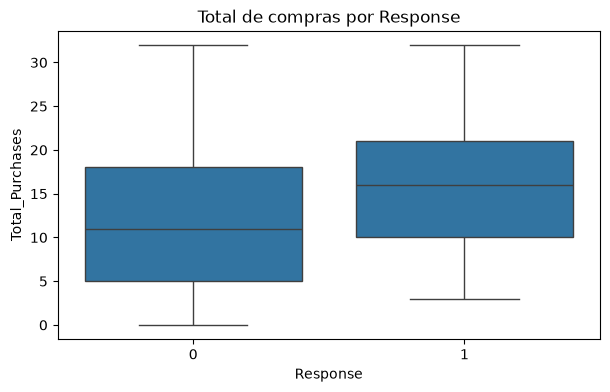

In [48]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_ml, x="Response", y="Total_Purchases")
plt.title("Total de compras por Response")
plt.xlabel("Response")
plt.ylabel("Total_Purchases")
plt.show()

### Interpretação

A quantidade total de compras representa o nível geral de atividade do consumidor e pode ajudar a diferenciar perfis com maior engajamento comercial.

In [49]:
numeric_df = df_ml.select_dtypes(include=np.number)

response_corr = (
    numeric_df
    .corr()["Response"]
    .drop("Response")
    .sort_values(key=abs, ascending=False)
)

response_corr.head(15)

Accepted_Campaigns      0.426035
AcceptedCmp5            0.326634
AcceptedCmp1            0.293982
Total_Spent             0.265298
AcceptedCmp3            0.254258
MntWines                0.247254
MntMeatProducts         0.236335
NumCatalogPurchases     0.220810
Recency                -0.198437
Customer_Tenure_Days    0.191712
AcceptedCmp4            0.177019
AcceptedCmp2            0.169293
Total_Children         -0.169163
Average_Ticket          0.165601
Total_Purchases         0.164688
Name: Response, dtype: float64

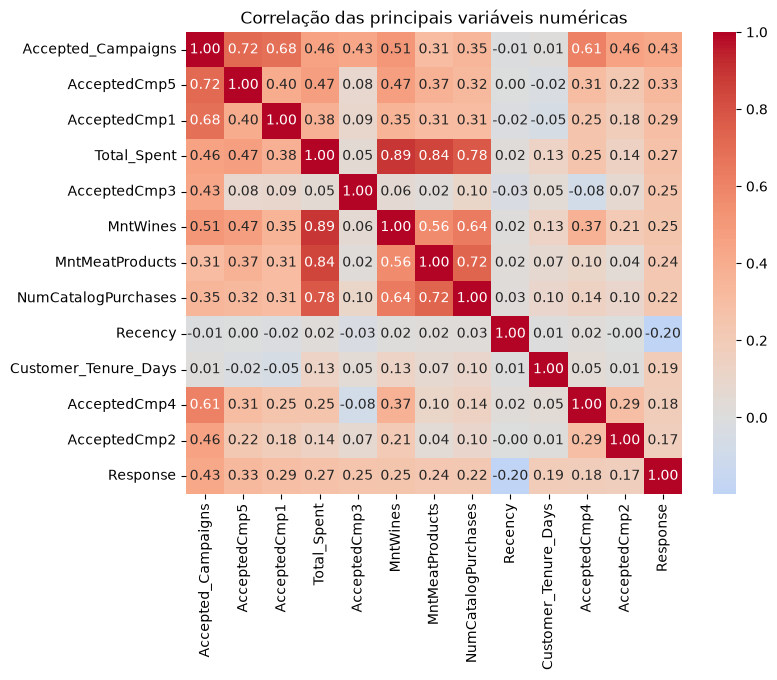

In [50]:
plt.figure(figsize=(8,6))

top_corr_cols = response_corr.head(12).index.tolist() + ["Response"]

sns.heatmap(
    df_ml[top_corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlação das principais variáveis numéricas")
plt.show()

### Interpretação

A correlação não determina causalidade, mas ajuda a identificar quais variáveis numéricas apresentam maior associação linear com `Response`. Esse resultado será utilizado apenas como apoio exploratório, sem selecionar variáveis com base no conjunto de teste.

## 7. Resumo do Feature Engineering

Foram criadas as seguintes variáveis:

- `Age`: idade aproximada do cliente.
- `Customer_Tenure_Days`: tempo de relacionamento com a empresa.
- `Total_Children`: quantidade total de filhos no domicílio.
- `Total_Spent`: gasto agregado nas categorias de produtos.
- `Total_Purchases`: quantidade total de compras nos principais canais.
- `Accepted_Campaigns`: quantidade de campanhas anteriores aceitas.
- `Average_Ticket`: gasto médio aproximado por compra.

Essas features representam características demográficas, relacionamento com a empresa e comportamento de consumo, seguindo a lógica do Case iFood apresentado em aula e ampliando a representação das variáveis originais.